# Lab 04 — Integrasi Data Visual ke Alur Kerja Digital

**Modul 5 · Computer Vision**

Notebook ini mendampingi **Materi 4** pada silabus: *integrasi data visual ke alur kerja
digital*.

Tiga lab sebelumnya menghasilkan potongan-potongan yang bekerja sendiri-sendiri. Di sini
semuanya dirangkai menjadi satu layanan yang berperilaku seperti sistem produksi:
punya kontrak data, antrean, percobaan ulang, penyaluran berdasarkan ambang, jejak audit,
dan ekspor ke sistem hilir.

| Bagian | Isi | Butir materi |
|---|---|---|
| 1 | Fondasi dari lab sebelumnya | — |
| 2 | Kelas `PipelineDokumen` | Arsitektur |
| 3 | Keluaran JSON baku dan versinya | Format data |
| 4 | Antrean, percobaan ulang, dan idempotensi | Keandalan |
| 5 | Penyaluran berdasarkan ambang keyakinan | Peran manusia |
| 6 | Jejak audit dan penyamaran data | Keamanan |
| 7 | Ekspor ke sistem hilir | Integrasi |
| 8 | Papan pantau operasional | Pemantauan |
| 9 | Latihan mandiri | — |

In [1]:
# --- Persiapan ------------------------------------------------------------
import os
import re
import json
import random
import difflib
import hashlib
import time
from collections import deque, Counter
from datetime import date, datetime, timezone, timedelta

import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

np.random.seed(21)
random.seed(21)
KELUARAN = "keluaran_lab04"
os.makedirs(KELUARAN, exist_ok=True)
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

OCR_NYATA = False
try:
    import pytesseract
    pytesseract.get_tesseract_version()
    OCR_NYATA = True
except Exception:
    pass
print("Mode OCR:", "MESIN NYATA (Tesseract)" if OCR_NYATA else "SIMULASI")

WIB = timezone(timedelta(hours=7))
TANGGAL_PROSES = date(2026, 8, 1)
VERSI_MODEL = "ocr-v2.3"
VERSI_SKEMA = "1.2.0"
print(f"versi model = {VERSI_MODEL} · versi skema = {VERSI_SKEMA}")

Mode OCR: SIMULASI
versi model = ocr-v2.3 · versi skema = 1.2.0


## 1. Fondasi dari lab sebelumnya

Sel berikut memuat versi ringkas dari kode Lab 01–03: pembuat dokumen contoh, gerbang
mutu citra, pembacaan OCR, ekstraksi field, normalisasi, dan data induk. Isinya sudah
dibahas panjang lebar di lab sebelumnya, jadi di sini cukup dijalankan sekali.

In [2]:
# ===== Fondasi Lab 01-03 (ringkas) ========================================
JALUR_FONT = ["/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
              "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf",
              "/Library/Fonts/Arial.ttf", "C:/Windows/Fonts/arial.ttf"]
JALUR_FONT_TEBAL = ["/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
                    "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
                    "C:/Windows/Fonts/arialbd.ttf"]
JALUR_FONT_MONO = ["/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",
                   "/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf",
                   "C:/Windows/Fonts/consola.ttf"]
HARGA = {"Kampas rem depan": 185000, "Filter oli": 42500, "Busi iridium": 96000}
AREA_FIELD, AREA_TOTAL = (40, 168, 690, 132), (452, 462, 268, 96)


def ambil_font(ukuran, tebal=False, mono=False):
    for jalur in (JALUR_FONT_MONO if mono else (JALUR_FONT_TEBAL if tebal else JALUR_FONT)):
        if os.path.exists(jalur):
            return ImageFont.truetype(jalur, ukuran)
    return ImageFont.load_default()


def buat_dokumen(no_faktur, tanggal, no_po, vendor, qty=(40, 60, 25), pakai_stempel=True):
    L, T = 760, 1040
    kanvas = Image.new("RGB", (L, T), (252, 252, 250))
    gbr = ImageDraw.Draw(kanvas)
    f_judul, f_tebal = ambil_font(26, tebal=True), ambil_font(15, tebal=True)
    f_biasa, f_kecil, f_mono = ambil_font(14), ambil_font(12), ambil_font(14, mono=True)
    gbr.text((48, 44), vendor, font=f_tebal, fill=(20, 20, 20))
    gbr.text((48, 66), "Jl. Contoh Industri No. 12, Jakarta", font=f_kecil, fill=(90, 90, 90))
    gbr.line([(48, 96), (L - 48, 96)], fill=(60, 60, 60), width=2)
    gbr.text((48, 118), "FAKTUR PENJUALAN", font=f_judul, fill=(15, 15, 15))
    y = 176
    for label, nilai in (("No. Faktur", no_faktur), ("Tanggal", tanggal),
                         ("No. PO", no_po), ("Vendor", vendor)):
        gbr.text((48, y), label, font=f_biasa, fill=(70, 70, 70))
        gbr.text((190, y), ":", font=f_biasa, fill=(70, 70, 70))
        gbr.text((214, y), nilai, font=f_mono, fill=(15, 15, 15))
        y += 32
    y += 22
    gbr.rectangle([(48, y), (L - 48, y + 28)], fill=(232, 236, 239))
    for x, teks in ((56, "URAIAN"), (392, "QTY"), (470, "HARGA"), (610, "JUMLAH")):
        gbr.text((x, y + 6), teks, font=f_tebal, fill=(30, 30, 30))
    y += 28
    subtotal = 0
    for (nama, harga), unit in zip(HARGA.items(), qty):
        nilai = unit * harga
        subtotal += nilai
        gbr.text((56, y + 7), nama, font=f_biasa, fill=(25, 25, 25))
        gbr.text((392, y + 7), str(unit), font=f_mono, fill=(25, 25, 25))
        gbr.text((470, y + 7), f"{harga:,}".replace(",", "."), font=f_mono, fill=(25, 25, 25))
        gbr.text((610, y + 7), f"{nilai:,}".replace(",", "."), font=f_mono, fill=(25, 25, 25))
        gbr.line([(48, y + 32), (L - 48, y + 32)], fill=(200, 205, 210), width=1)
        y += 33
    ppn = int(round(subtotal * 0.11))
    y += 18
    for label, nilai in (("Subtotal", subtotal), ("PPN 11%", ppn), ("TOTAL", subtotal + ppn)):
        tebal = label == "TOTAL"
        gbr.text((470, y), label, font=f_tebal if tebal else f_biasa, fill=(25, 25, 25))
        gbr.text((610, y), "Rp " + f"{nilai:,}".replace(",", "."),
                 font=ambil_font(14, tebal=tebal, mono=True), fill=(15, 15, 15))
        y += 28
    gbr.text((96, 780), "Hormat kami,", font=f_biasa, fill=(60, 60, 60))
    gbr.line([(110 + i * 9, 858 + int(22 * np.sin(i / 1.7)) - (i > 8) * 10) for i in range(18)],
             fill=(25, 40, 120), width=3, joint="curve")
    gbr.line([(96, 892), (300, 892)], fill=(90, 90, 90), width=1)
    if pakai_stempel:
        st = Image.new("RGBA", (210, 210), (0, 0, 0, 0))
        sd = ImageDraw.Draw(st)
        sd.ellipse([(8, 8), (202, 202)], outline=(178, 34, 52, 235), width=6)
        sd.text((58, 88), "LUNAS", font=ambil_font(30, tebal=True), fill=(178, 34, 52, 235))
        st = st.rotate(-14, resample=Image.BICUBIC)
        kanvas.paste(st, (462, 742), st)
    gbr.rectangle([(2, 2), (L - 3, T - 3)], outline=(215, 215, 215), width=2)
    citra = cv2.cvtColor(np.array(kanvas), cv2.COLOR_RGB2BGR)
    acuan = {"no_faktur": no_faktur, "tanggal": tanggal, "no_po": no_po, "vendor": vendor,
             "subtotal": subtotal, "ppn": ppn, "total": subtotal + ppn,
             "ada_stempel": pakai_stempel}
    return citra, acuan


# --- gerbang mutu citra (Lab 01) ---
def ukur_mutu(citra):
    abu = cv2.cvtColor(citra, cv2.COLOR_BGR2GRAY) if citra.ndim == 3 else citra
    halus = cv2.medianBlur(abu, 3)
    ambang = cv2.threshold(abu, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[0]
    tinta, kertas = abu[abu <= ambang], abu[abu > ambang]
    t, l = abu.shape
    kuadran = [abu[:t // 2, :l // 2], abu[:t // 2, l // 2:],
               abu[t // 2:, :l // 2], abu[t // 2:, l // 2:]]
    return {"ketajaman": float(cv2.Laplacian(halus, cv2.CV_64F).var()),
            "kontras": float(kertas.mean() - tinta.mean()) if tinta.size and kertas.size else 0.0,
            "beda_cahaya": float(max(np.mean(k) for k in kuadran) -
                                 min(np.mean(k) for k in kuadran))}


def gerbang_mutu(citra):
    u = ukur_mutu(citra)
    alasan = []
    if u["ketajaman"] < 100:
        alasan.append("citra kurang tajam")
    if u["kontras"] < 100:
        alasan.append("kontras tinta-kertas rendah")
    if u["beda_cahaya"] > 30:
        alasan.append("pencahayaan tidak merata")
    return (len(alasan) == 0), alasan, u


# --- OCR, ekstraksi, normalisasi (Lab 02-03) ---
def _pra_ocr(citra):
    abu = cv2.cvtColor(citra, cv2.COLOR_BGR2GRAY) if citra.ndim == 3 else citra
    besar = cv2.resize(abu, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
    return cv2.threshold(besar, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]


def _teks_acuan(acuan):
    rp = lambda n: "Rp " + f"{n:,}".replace(",", ".")
    return (f'No. Faktur : {acuan["no_faktur"]}\nTanggal : {acuan["tanggal"]}\n'
            f'No. PO : {acuan["no_po"]}\nVendor : {acuan["vendor"]}\n'
            f'Subtotal {rp(acuan["subtotal"])}\nPPN 11% {rp(acuan["ppn"])}\n'
            f'TOTAL {rp(acuan["total"])}')


def _simulasi_ocr(teks, peluang_galat=0.02, benih=1):
    acak = random.Random(benih)
    tukar = {"0": "O", "O": "0", "1": "l", "5": "S", "8": "B"}
    baris, nilai = [], []
    for satu in teks.split("\n"):
        huruf, rusak = [], 0
        for c in satu:
            if c in tukar and acak.random() < peluang_galat:
                huruf.append(tukar[c]); rusak += 1
            else:
                huruf.append(c)
        baris.append("".join(huruf))
        nilai.append(max(40.0, 96.0 - rusak * 20 - acak.random() * 5))
    return "\n".join(baris), float(np.mean(nilai))


def baca_dokumen(citra, acuan, peluang_galat=0.02, benih=1):
    if OCR_NYATA:
        bagian, keyakinan = [], []
        for (x, y, l, t) in (AREA_FIELD, AREA_TOTAL):
            siap = _pra_ocr(citra[y:y + t, x:x + l])
            bagian.append(pytesseract.image_to_string(siap, config="--psm 6").strip())
            data = pytesseract.image_to_data(siap, config="--psm 6",
                                             output_type=pytesseract.Output.DATAFRAME)
            data = data[data.conf.astype(float) > 0]
            if len(data):
                keyakinan.append(float(data.conf.astype(float).mean()))
        return "\n".join(bagian), (float(np.mean(keyakinan)) if keyakinan else 0.0)
    return _simulasi_ocr(_teks_acuan(acuan), peluang_galat, benih)


POLA = {
    "no_faktur": r"No\.?\s*Faktur\s*[:;]?\s*([A-Z0-9OIl/\.-]{10,})",
    "tanggal": r"Tanggal\s*[:;]?\s*([0-3OIl][0-9OIl][/\.-][01OIl][0-9OIl][/\.-][0-9OIl]{4})",
    "no_po": r"No\.?\s*PO\s*[:;]?\s*([A-Z0-9OIl-]{5,})",
    "vendor": r"Vendor\s*[:;]?\s*([A-Z][A-Z \.]{5,})",
    "total": r"(?m)^\s*TOTAL\b\D*?([0-9OIl][0-9OIl\.,\s]{4,})\s*$",
    "ppn": r"(?m)^\s*PPN\b[^%]*%?\s*(?:Rp\.?)?\s*([0-9OIl][0-9OIl\.,\s]{4,})\s*$",
}
GANTI_ANGKA = {"O": "0", "o": "0", "l": "1", "I": "1", "|": "1", "S": "5", "B": "8"}


def ekstrak_field(teks, keyakinan):
    hasil = {}
    for nama, pola in POLA.items():
        cocok = re.search(pola, teks, flags=re.IGNORECASE)
        nilai = cocok.group(1).strip() if cocok else None
        hasil[nama] = {"mentah": nilai,
                       "keyakinan": round(keyakinan / 100.0, 3) if nilai else 0.0}
    return hasil


def ke_angka(teks):
    if teks is None:
        return None
    angka = "".join(c for c in ("".join(GANTI_ANGKA.get(c, c) for c in teks)) if c.isdigit())
    return int(angka) if angka else None


def ke_tanggal(teks):
    if teks is None:
        return None
    bersih = "".join(GANTI_ANGKA.get(c, c) for c in teks.strip()).replace(".", "/").replace("-", "/")
    for bentuk in ("%d/%m/%Y", "%Y/%m/%d"):
        try:
            return datetime.strptime(bersih, bentuk).date()
        except ValueError:
            continue
    return None


def normalisasi(field):
    rapi = lambda s: re.sub(r"\s+", " ", s).strip().upper() if s else None
    return {"no_faktur": rapi(field["no_faktur"]["mentah"]),
            "tanggal": ke_tanggal(field["tanggal"]["mentah"]),
            "no_po": rapi(field["no_po"]["mentah"]),
            "vendor": rapi(field["vendor"]["mentah"]),
            "total": ke_angka(field["total"]["mentah"]),
            "ppn": ke_angka(field["ppn"]["mentah"])}


def hitung_total(qty):
    subtotal = sum(j * h for j, h in zip(qty, HARGA.values()))
    return subtotal + int(round(subtotal * 0.11))


MASTER_PO = pd.DataFrame([
    {"no_po": "PO-88231", "vendor": "PT MITRA SUKU CADANG", "nilai_po": hitung_total((40, 60, 25))},
    {"no_po": "PO-88233", "vendor": "PT SUMBER LOGAM PRIMA", "nilai_po": hitung_total((30, 40, 20))},
    {"no_po": "PO-88234", "vendor": "PT MITRA SUKU CADANG", "nilai_po": hitung_total((20, 30, 15))},
    {"no_po": "PO-88236", "vendor": "PT MITRA SUKU CADANG", "nilai_po": hitung_total((18, 22, 12))},
]).set_index("no_po")
MASTER_VENDOR = ["PT MITRA SUKU CADANG", "PT KARYA TEKNIK NUSANTARA", "PT SUMBER LOGAM PRIMA"]

print("Fondasi Lab 01-03 siap dipakai.")
print(MASTER_PO.to_string())

Fondasi Lab 01-03 siap dipakai.
                         vendor  nilai_po
no_po                                    
PO-88231   PT MITRA SUKU CADANG  13708500
PO-88233  PT SUMBER LOGAM PRIMA  10178700
PO-88234   PT MITRA SUKU CADANG   7120650
PO-88236   PT MITRA SUKU CADANG   6012870


## 2. Kelas `PipelineDokumen`

Di produksi, kode tidak berbentuk sel-sel notebook melainkan **satu objek dengan
kontrak yang jelas**: masuk sebuah citra, keluar sebuah catatan terstruktur. Semua
keputusan internal ikut dicatat agar dapat ditelusuri.

Perhatikan empat hal yang membuat kelas ini berperilaku seperti layanan sungguhan:

1. **Gerbang mutu di depan.** Citra buruk ditolak sebelum biaya OCR keluar.
2. **Setiap field membawa keyakinannya sendiri.**
3. **Keputusan disertai alasan**, bukan sekadar label.
4. **Setiap dokumen punya `doc_id` yang stabil**, diturunkan dari isi berkasnya.

In [3]:
def kemiripan(a, b):
    return difflib.SequenceMatcher(None, a or "", b or "").ratio()


class PipelineDokumen:
    def __init__(self, versi_model=VERSI_MODEL, versi_skema=VERSI_SKEMA,
                 ambang_lolos=0.85, toleransi_nilai=0.02):
        self.versi_model = versi_model
        self.versi_skema = versi_skema
        self.ambang_lolos = ambang_lolos
        self.toleransi_nilai = toleransi_nilai
        self.riwayat_kunci = set()

    # --- identitas dokumen -------------------------------------------------
    @staticmethod
    def buat_doc_id(citra):
        # Diturunkan dari isi berkas: berkas sama selalu menghasilkan id sama.
        # Inilah dasar idempotensi - lihat bagian 4.
        sidik = hashlib.sha256(cv2.imencode(".png", citra)[1].tobytes()).hexdigest()
        return "DOC-" + sidik[:16].upper()

    # --- aturan validasi ringkas ------------------------------------------
    def _validasi(self, nilai, konteks):
        pelanggaran = []

        def catat(kode, kritis, pesan):
            pelanggaran.append({"kode": kode, "kritis": kritis, "pesan": pesan})

        if not nilai["no_faktur"] or not re.match(r"^INV/\d{4}/\d{2}/\d{5}$", nilai["no_faktur"]):
            catat("F01", True, f'format nomor faktur tidak sah: {nilai["no_faktur"]}')
        if nilai["tanggal"] is None:
            catat("F03", True, "tanggal tidak terbaca")
        elif nilai["tanggal"] > TANGGAL_PROSES:
            catat("F04", False, f'tanggal {nilai["tanggal"]} berada di masa depan')
        if not nilai["total"]:
            catat("F05", True, "nilai total tidak terbaca")
        if nilai["no_po"] not in MASTER_PO.index:
            catat("E01", True, f'nomor PO {nilai["no_po"]} tidak ada di data induk')
        else:
            nilai_po = int(MASTER_PO.loc[nilai["no_po"], "nilai_po"])
            if nilai["total"]:
                selisih = abs(nilai["total"] - nilai_po) / max(1, nilai_po)
                if selisih > self.toleransi_nilai:
                    catat("E06", True, f'selisih {selisih:.1%} terhadap nilai PO')
            vendor_po = MASTER_PO.loc[nilai["no_po"], "vendor"]
            if kemiripan(nilai["vendor"], vendor_po) < 0.88:
                catat("E05", True, f'vendor tidak sesuai PO (harusnya {vendor_po})')
        kunci = (nilai["no_faktur"], nilai["vendor"])
        if kunci in self.riwayat_kunci:
            catat("E07", True, f'nomor faktur {nilai["no_faktur"]} sudah pernah diproses')
        if not konteks["ada_stempel"]:
            catat("K02", False, "stempel pengesahan tidak terdeteksi")
        return pelanggaran, kunci

    # --- pemrosesan satu dokumen ------------------------------------------
    def proses(self, citra, acuan, sumber="app_mobile", benih=1):
        mulai = time.perf_counter()
        doc_id = self.buat_doc_id(citra)
        catatan = {
            "skema_versi": self.versi_skema,
            "doc_id": doc_id,
            "jenis": "faktur_penjualan",
            "sumber": sumber,
            "model_versi": self.versi_model,
            "fields": {},
            "validasi": {"status": None, "aturan_gagal": [], "alasan": [], "skor": 0.0},
            "audit": {"diproses": datetime.now(WIB).isoformat(timespec="seconds"),
                      "durasi_ms": None, "gerbang_mutu": None},
        }

        lolos_mutu, alasan_mutu, ukuran = gerbang_mutu(citra)
        catatan["audit"]["gerbang_mutu"] = {"lolos": lolos_mutu,
                                            "alasan": alasan_mutu,
                                            "ukuran": {k: round(v, 1) for k, v in ukuran.items()}}
        if not lolos_mutu:
            # Bentuk catatan tetap dipertahankan walau pemrosesan berhenti lebih awal,
            # supaya kontrak data tidak berubah-ubah bagi sistem hilir.
            catatan["fields"] = {nama: {"nilai": None, "conf": 0.0} for nama in POLA}
            catatan["validasi"].update({"status": "TOLAK", "aturan_gagal": ["M01"],
                                        "alasan": ["mutu citra tidak memadai: " +
                                                   "; ".join(alasan_mutu)], "skor": 0.0})
            catatan["audit"]["durasi_ms"] = round((time.perf_counter() - mulai) * 1000, 1)
            return catatan

        teks, keyakinan = baca_dokumen(citra, acuan, benih=benih)
        field = ekstrak_field(teks, keyakinan)
        nilai = normalisasi(field)
        catatan["fields"] = {
            nama: {"nilai": (nilai[nama].isoformat() if isinstance(nilai[nama], date)
                             else nilai[nama]),
                   "conf": field[nama]["keyakinan"]}
            for nama in POLA
        }

        konteks = {"ada_stempel": bool(acuan["ada_stempel"])}
        pelanggaran, kunci = self._validasi(nilai, konteks)
        keyakinan_min = min((f["conf"] for f in catatan["fields"].values()), default=0.0)

        if any(p["kritis"] for p in pelanggaran):
            status = "TOLAK"
        elif pelanggaran or keyakinan_min < self.ambang_lolos:
            status = "TINJAU"
        else:
            status = "LOLOS"
            self.riwayat_kunci.add(kunci)

        if keyakinan_min < self.ambang_lolos and status == "TINJAU" and not pelanggaran:
            pelanggaran.append({"kode": "K03", "kritis": False,
                                "pesan": f"keyakinan terendah {keyakinan_min:.2f} "
                                         f"di bawah ambang {self.ambang_lolos}"})

        catatan["validasi"] = {
            "status": status,
            "aturan_gagal": [p["kode"] for p in pelanggaran],
            "alasan": [p["pesan"] for p in pelanggaran],
            "skor": round(max(0.0, keyakinan_min * (1 - 0.12 * len(pelanggaran))), 3),
            "keyakinan_min": round(keyakinan_min, 3),
        }
        catatan["audit"]["durasi_ms"] = round((time.perf_counter() - mulai) * 1000, 1)
        return catatan


pipeline = PipelineDokumen()
citra_uji, acuan_uji = buat_dokumen("INV/2026/07/00184", "18/07/2026",
                                    "PO-88231", "PT MITRA SUKU CADANG")
catatan_uji = pipeline.proses(citra_uji, acuan_uji)
print("doc_id :", catatan_uji["doc_id"])
print("status :", catatan_uji["validasi"]["status"])
print("durasi :", catatan_uji["audit"]["durasi_ms"], "ms")

doc_id : DOC-EFD6AB998C893B41
status : TOLAK
durasi : 27.1 ms


## 3. Keluaran JSON baku dan versinya

Kontrak data adalah bagian tersulit dan terpenting dari integrasi. Sekali sistem hilir
membaca sebuah field, nama dan tipenya tidak boleh berubah diam-diam.

Aturan main yang dipakai di sini:

- Setiap catatan membawa `skema_versi` dan `model_versi`. Sistem hilir bisa memilih
  perlakuan berbeda per versi, dan setiap keputusan lama tetap dapat ditelusuri
  menggunakan versi model yang sungguh dipakai saat itu.
- Menambah field baru = perubahan kecil (`1.2.0` → `1.3.0`), aman bagi pembaca lama.
- Mengubah arti atau menghapus field = perubahan besar (`1.x` → `2.0.0`), harus
  diumumkan dan diberi masa transisi.
- Setiap nilai selalu berpasangan dengan `conf`, sehingga sistem hilir dapat menerapkan
  ambangnya sendiri.

In [4]:
print(json.dumps(catatan_uji, indent=2, ensure_ascii=False)[:1800])

{
  "skema_versi": "1.2.0",
  "doc_id": "DOC-EFD6AB998C893B41",
  "jenis": "faktur_penjualan",
  "sumber": "app_mobile",
  "model_versi": "ocr-v2.3",
  "fields": {
    "no_faktur": {
      "nilai": "INV/2026/07/00184",
      "conf": 0.905
    },
    "tanggal": {
      "nilai": "2026-07-18",
      "conf": 0.905
    },
    "no_po": {
      "nilai": "P0-88231",
      "conf": 0.905
    },
    "vendor": {
      "nilai": "PT MITRA SUKU CADANG",
      "conf": 0.905
    },
    "total": {
      "nilai": 13708500,
      "conf": 0.905
    },
    "ppn": {
      "nilai": 1358500,
      "conf": 0.905
    }
  },
  "validasi": {
    "status": "TOLAK",
    "aturan_gagal": [
      "E01"
    ],
    "alasan": [
      "nomor PO P0-88231 tidak ada di data induk"
    ],
    "skor": 0.796,
    "keyakinan_min": 0.905
  },
  "audit": {
    "diproses": "2026-08-14T00:30:44+07:00",
    "durasi_ms": 27.1,
    "gerbang_mutu": {
      "lolos": true,
      "alasan": [],
      "ukuran": {
        "ketajaman": 935.8,
 

In [5]:
# Pemeriksa skema sederhana: jaring pengaman agar kontrak data tidak diam-diam berubah
SKEMA_WAJIB = {
    "skema_versi": str, "doc_id": str, "jenis": str, "sumber": str,
    "model_versi": str, "fields": dict, "validasi": dict, "audit": dict,
}
FIELD_WAJIB = ["no_faktur", "tanggal", "no_po", "vendor", "total"]
STATUS_SAH = {"LOLOS", "TINJAU", "TOLAK"}


def periksa_skema(catatan):
    masalah = []
    for kunci, tipe in SKEMA_WAJIB.items():
        if kunci not in catatan:
            masalah.append(f"field wajib hilang: {kunci}")
        elif not isinstance(catatan[kunci], tipe):
            masalah.append(f"tipe {kunci} seharusnya {tipe.__name__}")
    if isinstance(catatan.get("fields"), dict):
        for nama in FIELD_WAJIB:
            if nama not in catatan["fields"]:
                masalah.append(f"field hasil ekstraksi hilang: {nama}")
            elif "conf" not in catatan["fields"][nama]:
                masalah.append(f"field {nama} tidak membawa skor keyakinan")
    status = catatan.get("validasi", {}).get("status")
    if status not in STATUS_SAH:
        masalah.append(f"status tidak dikenal: {status}")
    return (len(masalah) == 0), masalah


print("catatan sah? ->", periksa_skema(catatan_uji))

rusak = json.loads(json.dumps(catatan_uji))
rusak["validasi"]["status"] = "OK"          # status di luar daftar
del rusak["fields"]["no_po"]                 # field wajib dihapus
print("catatan rusak ->", periksa_skema(rusak))

catatan sah? -> (True, [])
catatan rusak -> (False, ['field hasil ekstraksi hilang: no_po', 'status tidak dikenal: OK'])


## 4. Antrean, percobaan ulang, dan idempotensi

Tiga prinsip pada slide *Arsitektur Integrasi* diwujudkan di sini:

- **Asinkron lewat antrean.** Petugas yang mengunggah tidak menunggu model selesai.
- **Percobaan ulang berbatas.** Kegagalan sementara (jaringan, layanan sibuk) dicoba
  ulang beberapa kali, lalu dialihkan ke *dead letter* untuk diperiksa manusia.
- **Idempotensi.** `doc_id` diturunkan dari isi berkas, sehingga berkas yang sama
  dikirim dua kali tidak menghasilkan dua catatan di sistem keuangan.

Tanpa ketiganya, satu gangguan jaringan bisa berujung pada pembayaran ganda.

In [6]:
BERKAS_MASUK = [
    ("INV/2026/07/00184", "18/07/2026", "PO-88231", "PT MITRA SUKU CADANG", (40, 60, 25), True, "app_mobile"),
    ("INV/2026/07/00187", "18/07/2026", "PO-88233", "PT SUMBER LOGAM PRIMA", (30, 40, 20), True, "pemindai"),
    ("INV/2026/07/00188", "21/07/2026", "PO-88234", "PT MITRA SUKU CADANG", (20, 30, 15), True, "surel"),
    ("INV/2026/07/00190", "23/07/2026", "PO-88236", "PT MITRA SUKU CADANG", (18, 22, 12), False, "app_mobile"),
    ("INV/2026/09/00191", "18/09/2026", "PO-88231", "PT MITRA SUKU CADANG", (40, 60, 25), True, "app_mobile"),
    ("INV/2026/07/00192", "22/07/2026", "PO-99999", "PT MITRA SUKU CADANG", (40, 60, 25), True, "surel"),
]

antrean = deque()
for i, (fak, tgl, po, ven, qty, stempel, sumber) in enumerate(BERKAS_MASUK):
    citra, acuan = buat_dokumen(fak, tgl, po, ven, qty, stempel)
    antrean.append({"citra": citra, "acuan": acuan, "sumber": sumber, "percobaan": 0, "benih": i})

# Dokumen pertama sengaja diunggah dua kali - inilah uji idempotensi
ulang = dict(antrean[0])
ulang["sumber"] = "surel"
ulang["percobaan"] = 0
antrean.append(ulang)

# Citra rusak: kabur berat, harus tertahan di gerbang mutu
citra_rusak, acuan_rusak = buat_dokumen("INV/2026/07/00193", "24/07/2026",
                                        "PO-88234", "PT MITRA SUKU CADANG", (20, 30, 15))
antrean.append({"citra": cv2.GaussianBlur(citra_rusak, (15, 15), 0), "acuan": acuan_rusak,
                "sumber": "app_mobile", "percobaan": 0, "benih": 99})

print(f"Antrean berisi {len(antrean)} pekerjaan")

MAKS_PERCOBAAN = 3
PELUANG_GANGGUAN = 0.25  # simulasi kegagalan sementara pada layanan


def proses_dengan_gangguan(pipeline, pekerjaan, acak):
    # Meniru layanan yang sesekali gagal karena sebab sementara
    if acak.random() < PELUANG_GANGGUAN and pekerjaan["percobaan"] < 2:
        raise ConnectionError("layanan OCR sedang sibuk")
    return pipeline.proses(pekerjaan["citra"], pekerjaan["acuan"],
                           sumber=pekerjaan["sumber"], benih=pekerjaan["benih"])


pipeline = PipelineDokumen()
acak = random.Random(4)
sudah_diproses, hasil, dead_letter, log_jalan = {}, [], [], []

while antrean:
    pekerjaan = antrean.popleft()
    doc_id = PipelineDokumen.buat_doc_id(pekerjaan["citra"])

    if doc_id in sudah_diproses:
        log_jalan.append({"doc_id": doc_id, "peristiwa": "dilewati (idempoten)",
                          "percobaan": pekerjaan["percobaan"] + 1,
                          "catatan": f'sudah diproses dari sumber {sudah_diproses[doc_id]}'})
        continue

    pekerjaan["percobaan"] += 1
    try:
        catatan = proses_dengan_gangguan(pipeline, pekerjaan, acak)
        sudah_diproses[doc_id] = pekerjaan["sumber"]
        hasil.append(catatan)
        log_jalan.append({"doc_id": doc_id, "peristiwa": "berhasil",
                          "percobaan": pekerjaan["percobaan"],
                          "catatan": catatan["validasi"]["status"]})
    except Exception as galat:
        if pekerjaan["percobaan"] < MAKS_PERCOBAAN:
            antrean.append(pekerjaan)  # dikembalikan ke ekor antrean
            log_jalan.append({"doc_id": doc_id, "peristiwa": "gagal - dicoba ulang",
                              "percobaan": pekerjaan["percobaan"], "catatan": str(galat)})
        else:
            dead_letter.append(pekerjaan)
            log_jalan.append({"doc_id": doc_id, "peristiwa": "masuk dead letter",
                              "percobaan": pekerjaan["percobaan"], "catatan": str(galat)})

print(pd.DataFrame(log_jalan).to_string(index=False))
print(f"\nberhasil={len(hasil)}  dead_letter={len(dead_letter)}  unik={len(sudah_diproses)}")

Antrean berisi 8 pekerjaan
              doc_id            peristiwa  percobaan                          catatan
DOC-EFD6AB998C893B41 gagal - dicoba ulang          1         layanan OCR sedang sibuk
DOC-65DB62C875056C2B gagal - dicoba ulang          1         layanan OCR sedang sibuk
DOC-8021E530A235B124             berhasil          1                            LOLOS
DOC-3389CE2E5B1B6385 gagal - dicoba ulang          1         layanan OCR sedang sibuk
DOC-3D4FDE72C77C6536 gagal - dicoba ulang          1         layanan OCR sedang sibuk
DOC-59B7B0877A0F2DB8             berhasil          1                            TOLAK
DOC-EFD6AB998C893B41             berhasil          1                            TOLAK
DOC-2CA6236391B1FDF9             berhasil          1                            TOLAK
DOC-EFD6AB998C893B41 dilewati (idempoten)          2 sudah diproses dari sumber surel
DOC-65DB62C875056C2B             berhasil          2                            TOLAK
DOC-3389CE2E5B1B6385       

Baris **"dilewati (idempoten)"** adalah inti bagian ini. Dokumen yang sama diunggah dua
kali lewat dua jalur berbeda (aplikasi ponsel dan surel), tetapi hanya diproses sekali
karena `doc_id`-nya diturunkan dari isi berkas.

Perhatikan juga bahwa pekerjaan yang gagal **tidak hilang**: ia kembali ke ekor antrean
dan dicoba lagi. Setelah batas percobaan habis, ia masuk *dead letter* untuk ditangani
manusia — bukan diam-diam menghilang.

## 5. Penyaluran berdasarkan ambang keyakinan

Sekarang hasil pemrosesan dibagi ke tiga jalur, persis seperti slide *Ambang Keyakinan
dan Peran Manusia*.

              doc_id     sumber         no_faktur      total  keyakinan_min status                               jalur aturan_gagal  durasi_ms
DOC-8021E530A235B124      surel INV/2026/07/00188  7120650.0          0.935  LOLOS posting otomatis ke sistem keuangan            -       24.9
DOC-59B7B0877A0F2DB8      surel INV/2026/07/00192 13708500.0          0.876  TOLAK            dikembalikan ke pengirim          E01       23.8
DOC-EFD6AB998C893B41      surel INV/2026/07/00184        NaN          0.000  TOLAK            dikembalikan ke pengirim          F05       23.8
DOC-2CA6236391B1FDF9 app_mobile               NaN        NaN          0.000  TOLAK            dikembalikan ke pengirim          M01       26.1
DOC-65DB62C875056C2B   pemindai INV/2026/07/00187 10178700.0          0.905  TOLAK            dikembalikan ke pengirim          E01       22.9
DOC-3389CE2E5B1B6385 app_mobile INV/2026/07/00190  6012870.0          0.944 TINJAU            antrean tinjauan petugas          K02       22.9

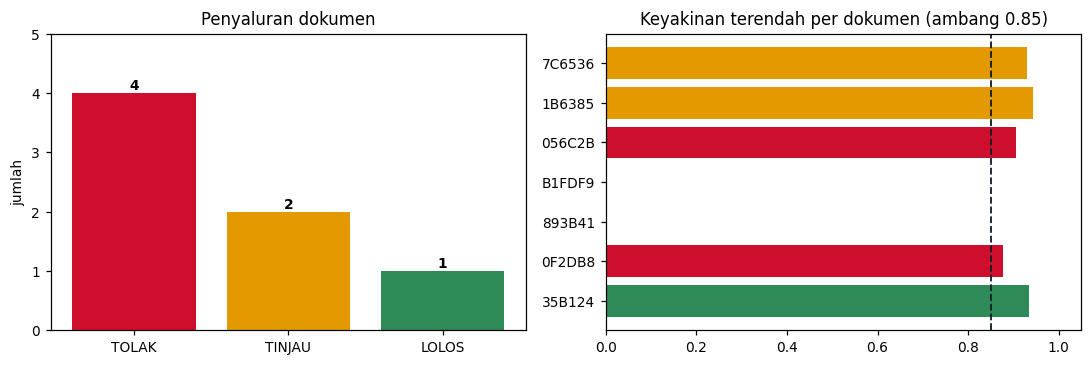

In [7]:
def nilai_field(catatan, nama):
    # Akses aman: dokumen yang berhenti di gerbang mutu tidak punya nilai field
    return catatan["fields"].get(nama, {}).get("nilai")


JALUR = {"LOLOS": "posting otomatis ke sistem keuangan",
         "TINJAU": "antrean tinjauan petugas",
         "TOLAK": "dikembalikan ke pengirim"}

ringkas = pd.DataFrame([{
    "doc_id": h["doc_id"],
    "sumber": h["sumber"],
    "no_faktur": nilai_field(h, "no_faktur"),
    "total": nilai_field(h, "total"),
    "keyakinan_min": h["validasi"].get("keyakinan_min", 0.0),
    "status": h["validasi"]["status"],
    "jalur": JALUR[h["validasi"]["status"]],
    "aturan_gagal": ", ".join(h["validasi"]["aturan_gagal"]) or "-",
    "durasi_ms": h["audit"]["durasi_ms"],
} for h in hasil])
print(ringkas.to_string(index=False))

hitung = ringkas["status"].value_counts()
warna = {"LOLOS": "#2E8B57", "TINJAU": "#E39A00", "TOLAK": "#CE0E2D"}
fig, (kiri, kanan) = plt.subplots(1, 2, figsize=(10, 3.4))
kiri.bar(hitung.index, hitung.values, color=[warna[k] for k in hitung.index])
for i, (nama, jml) in enumerate(hitung.items()):
    kiri.text(i, jml + 0.05, str(jml), ha="center", fontweight="bold")
kiri.set_title("Penyaluran dokumen")
kiri.set_ylabel("jumlah")
kiri.set_ylim(0, max(hitung.values) + 1)

kanan.barh(ringkas["doc_id"].str[-6:], ringkas["keyakinan_min"],
           color=[warna[s] for s in ringkas["status"]])
kanan.axvline(pipeline.ambang_lolos, color="#0F1E2B", linestyle="--", linewidth=1.2)
kanan.set_xlim(0, 1.05)
kanan.set_title(f"Keyakinan terendah per dokumen (ambang {pipeline.ambang_lolos})")
plt.tight_layout()
plt.show()

 ambang  LOLOS  TOLAK  TINJAU  % otomatis
   0.70    1.0      4       2        14.3
   0.80    1.0      4       2        14.3
   0.85    1.0      4       2        14.3
   0.90    1.0      4       2        14.3
   0.95    0.0      4       3         0.0
   0.99    0.0      4       3         0.0


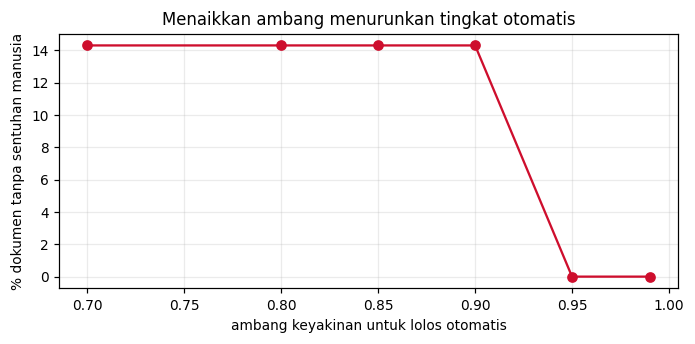

In [8]:
# Bagaimana kalau ambangnya digeser? Simulasi tanpa memproses ulang dokumen
def salur_ulang(hasil, ambang):
    keluar = Counter()
    for h in hasil:
        if any(k in ("F01", "F03", "F05", "E01", "E05", "E06", "E07", "M01")
               for k in h["validasi"]["aturan_gagal"]):
            keluar["TOLAK"] += 1
        elif (h["validasi"].get("keyakinan_min", 0) < ambang or
              [k for k in h["validasi"]["aturan_gagal"] if k in ("F04", "K02", "K03")]):
            keluar["TINJAU"] += 1
        else:
            keluar["LOLOS"] += 1
    return keluar


ambang_uji = [0.70, 0.80, 0.85, 0.90, 0.95, 0.99]
tabel_ambang = pd.DataFrame([{"ambang": a, **salur_ulang(hasil, a)} for a in ambang_uji]).fillna(0)
tabel_ambang["% otomatis"] = (100 * tabel_ambang.get("LOLOS", 0) / len(hasil)).round(1)
print(tabel_ambang.to_string(index=False))

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot(tabel_ambang["ambang"], tabel_ambang["% otomatis"], marker="o", color="#CE0E2D")
ax.set_xlabel("ambang keyakinan untuk lolos otomatis")
ax.set_ylabel("% dokumen tanpa sentuhan manusia")
ax.set_title("Menaikkan ambang menurunkan tingkat otomatis")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Grafik ini adalah alat perundingan dengan pemilik proses: **berapa persen otomatis yang
kita inginkan, dan berapa risiko yang bersedia kita tanggung?** Keputusannya bukan
keputusan teknis, melainkan keputusan bisnis yang harus diambil sadar angka.

## 6. Jejak audit dan penyamaran data

Dua kewajiban yang sering terlupakan sampai audit datang:

1. **Jejak audit** — setiap catatan disimpan apa adanya, satu baris JSON per dokumen
   (format JSONL), lengkap dengan versi model dan waktu proses. Format ini mudah
   ditambahi, mudah dibaca ulang, dan tahan terhadap berkas yang membesar.
2. **Penyamaran data** — catatan log teknis yang dibaca banyak orang tidak boleh memuat
   data pribadi atau komersial secara utuh.

In [9]:
BERKAS_AUDIT = os.path.join(KELUARAN, "jejak_audit.jsonl")
with open(BERKAS_AUDIT, "w", encoding="utf-8") as f:
    for catatan in hasil:
        f.write(json.dumps(catatan, ensure_ascii=False) + "\n")
print(f"{len(hasil)} catatan ditulis ke {os.path.abspath(BERKAS_AUDIT)}")

with open(BERKAS_AUDIT, encoding="utf-8") as f:
    dibaca = [json.loads(baris) for baris in f]
print("dibaca kembali:", len(dibaca), "catatan · semua sah?",
      all(periksa_skema(c)[0] for c in dibaca))


def samarkan(teks, tampil_depan=4, tampil_belakang=3):
    if not teks:
        return teks
    teks = str(teks)
    if len(teks) <= tampil_depan + tampil_belakang:
        return "*" * len(teks)
    # Catatan: teks[-0:] mengembalikan SELURUH teks, bukan string kosong.
    # Tanpa penjagaan ini, penyamaran justru membocorkan data secara utuh.
    ekor = teks[-tampil_belakang:] if tampil_belakang > 0 else ""
    return teks[:tampil_depan] + "*" * (len(teks) - tampil_depan - tampil_belakang) + ekor


def baris_log(catatan):
    return {
        "waktu": catatan["audit"]["diproses"],
        "doc_id": catatan["doc_id"],
        "sumber": catatan["sumber"],
        "no_faktur": samarkan(nilai_field(catatan, "no_faktur")),
        "vendor": samarkan(nilai_field(catatan, "vendor"), 5, 0),
        "total": "***",                       # nilai komersial tidak ditulis ke log
        "status": catatan["validasi"]["status"],
        "durasi_ms": catatan["audit"]["durasi_ms"],
    }


print("\nContoh baris log operasional (aman untuk dibaca tim pendukung):")
print(pd.DataFrame([baris_log(c) for c in hasil]).to_string(index=False))

7 catatan ditulis ke e:\Paket_Latihan_ML_AHM\Modul 5\keluaran_lab04\jejak_audit.jsonl
dibaca kembali: 7 catatan · semua sah? True

Contoh baris log operasional (aman untuk dibaca tim pendukung):
                    waktu               doc_id     sumber         no_faktur                vendor total status  durasi_ms
2026-08-14T00:30:44+07:00 DOC-8021E530A235B124      surel INV/**********188  PT MI***************   ***  LOLOS       24.9
2026-08-14T00:30:44+07:00 DOC-59B7B0877A0F2DB8      surel INV/**********192  PT MI***************   ***  TOLAK       23.8
2026-08-14T00:30:44+07:00 DOC-EFD6AB998C893B41      surel INV/**********184  PT MI***************   ***  TOLAK       23.8
2026-08-14T00:30:44+07:00 DOC-2CA6236391B1FDF9 app_mobile               NaN                   NaN   ***  TOLAK       26.1
2026-08-14T00:30:44+07:00 DOC-65DB62C875056C2B   pemindai INV/**********187 PT SU****************   ***  TOLAK       22.9
2026-08-14T00:30:44+07:00 DOC-3389CE2E5B1B6385 app_mobile INV/**********1

Perbedaannya harus jelas: **jejak audit** disimpan lengkap di penyimpanan berakses
terbatas, sedangkan **log operasional** yang dibaca tim pendukung sehari-hari hanya
memuat data yang sudah disamarkan. Keduanya bukan hal yang sama dan tidak boleh
disimpan di tempat yang sama.

## 7. Ekspor ke sistem hilir

Dua jalur keluar yang paling lazim: berkas untuk unggah massal, dan pemanggilan API.
Keduanya membawa **kunci idempotensi** agar pengiriman ulang tidak menghasilkan catatan
ganda di sistem keuangan.

Fungsi `kirim_ke_erp` di bawah ini **tidak memanggil jaringan**; ia hanya meniru
perilaku endpoint sungguhan agar polanya dapat dipelajari dengan aman.

In [10]:
siap_posting = [h for h in hasil if h["validasi"]["status"] == "LOLOS"]

ekspor = pd.DataFrame([{
    "doc_id": h["doc_id"],
    "no_faktur": nilai_field(h, "no_faktur"),
    "tanggal": nilai_field(h, "tanggal"),
    "no_po": nilai_field(h, "no_po"),
    "vendor": nilai_field(h, "vendor"),
    "total": nilai_field(h, "total"),
    "ppn": nilai_field(h, "ppn"),
    "model_versi": h["model_versi"],
    "kunci_idempotensi": h["doc_id"],
} for h in siap_posting])

BERKAS_EKSPOR = os.path.join(KELUARAN, "posting_keuangan.csv")
ekspor.to_csv(BERKAS_EKSPOR, index=False)
print(f"{len(ekspor)} baris siap posting -> {os.path.abspath(BERKAS_EKSPOR)}")
print(ekspor.to_string(index=False))


class ErpTiruan:
    # Meniru endpoint sistem keuangan: menolak muatan tak lengkap dan
    # mengabaikan pengiriman ulang dengan kunci idempotensi yang sama.
    def __init__(self):
        self.tersimpan = {}

    def posting(self, muatan):
        wajib = ("no_faktur", "no_po", "total", "kunci_idempotensi")
        kurang = [k for k in wajib if not muatan.get(k)]
        if kurang:
            return {"kode": 422, "pesan": f"field wajib kosong: {', '.join(kurang)}"}
        kunci = muatan["kunci_idempotensi"]
        if kunci in self.tersimpan:
            return {"kode": 200, "pesan": "sudah pernah diposting (idempoten)",
                    "id_jurnal": self.tersimpan[kunci]}
        id_jurnal = "JRN-" + hashlib.md5(kunci.encode()).hexdigest()[:8].upper()
        self.tersimpan[kunci] = id_jurnal
        return {"kode": 201, "pesan": "berhasil diposting", "id_jurnal": id_jurnal}


erp = ErpTiruan()
print("\n--- Pengiriman pertama ---")
for muatan in ekspor.to_dict("records"):
    print(muatan["no_faktur"], "->", erp.posting(muatan))

print("\n--- Pengiriman ulang seluruh berkas yang sama ---")
for muatan in ekspor.to_dict("records"):
    print(muatan["no_faktur"], "->", erp.posting(muatan))

print("\n--- Muatan tidak lengkap ---")
cacat = dict(ekspor.to_dict("records")[0])
cacat["no_po"] = None
print(erp.posting(cacat))

1 baris siap posting -> e:\Paket_Latihan_ML_AHM\Modul 5\keluaran_lab04\posting_keuangan.csv
              doc_id         no_faktur    tanggal    no_po               vendor   total    ppn model_versi    kunci_idempotensi
DOC-8021E530A235B124 INV/2026/07/00188 2026-07-21 PO-88234 PT MITRA SUKU CADANG 7120650 705650    ocr-v2.3 DOC-8021E530A235B124

--- Pengiriman pertama ---
INV/2026/07/00188 -> {'kode': 201, 'pesan': 'berhasil diposting', 'id_jurnal': 'JRN-39839F26'}

--- Pengiriman ulang seluruh berkas yang sama ---
INV/2026/07/00188 -> {'kode': 200, 'pesan': 'sudah pernah diposting (idempoten)', 'id_jurnal': 'JRN-39839F26'}

--- Muatan tidak lengkap ---
{'kode': 422, 'pesan': 'field wajib kosong: no_po'}


## 8. Papan pantau operasional

Angka yang perlu dilihat setiap hari oleh pemilik proses. Semuanya berasal dari catatan
audit yang sudah kita tulis — tidak perlu sistem pemantauan terpisah untuk memulai.

Dokumen diproses              : 7
Tingkat otomatis penuh (STP)  : 14.3%
Perlu tinjauan manusia        : 28.6%
Ditolak / dikembalikan        : 57.1%
Waktu proses rata-rata        : 24 ms
Waktu proses persentil 90     : 25 ms
Pekerjaan di dead letter      : 0


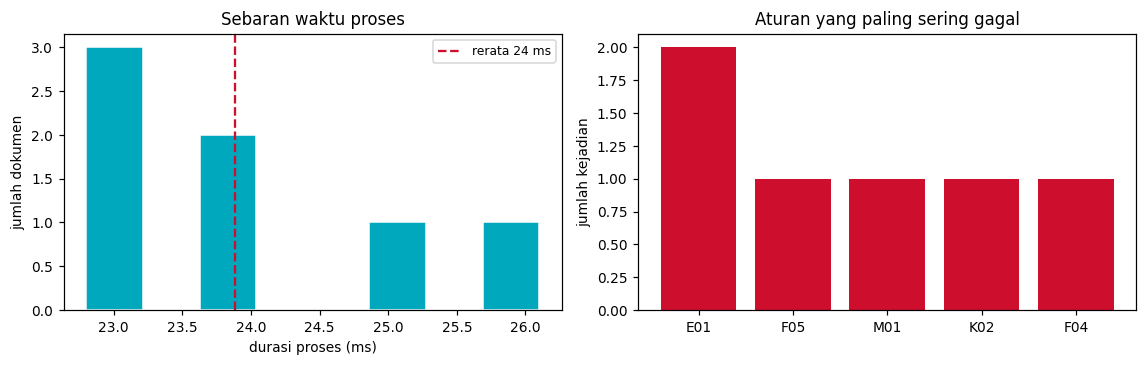

In [11]:
total_dokumen = len(hasil)
tingkat_otomatis = 100 * sum(h["validasi"]["status"] == "LOLOS" for h in hasil) / total_dokumen
tingkat_tinjau = 100 * sum(h["validasi"]["status"] == "TINJAU" for h in hasil) / total_dokumen
tingkat_tolak = 100 * sum(h["validasi"]["status"] == "TOLAK" for h in hasil) / total_dokumen
durasi = [h["audit"]["durasi_ms"] for h in hasil]
gagal_terbanyak = Counter(k for h in hasil for k in h["validasi"]["aturan_gagal"])

print(f'{"Dokumen diproses":30s}: {total_dokumen}')
print(f'{"Tingkat otomatis penuh (STP)":30s}: {tingkat_otomatis:.1f}%')
print(f'{"Perlu tinjauan manusia":30s}: {tingkat_tinjau:.1f}%')
print(f'{"Ditolak / dikembalikan":30s}: {tingkat_tolak:.1f}%')
print(f'{"Waktu proses rata-rata":30s}: {np.mean(durasi):.0f} ms')
print(f'{"Waktu proses persentil 90":30s}: {np.percentile(durasi, 90):.0f} ms')
print(f'{"Pekerjaan di dead letter":30s}: {len(dead_letter)}')

fig, (kiri, kanan) = plt.subplots(1, 2, figsize=(10.5, 3.4))
kiri.hist(durasi, bins=8, color="#00A8BE", edgecolor="white")
kiri.axvline(float(np.mean(durasi)), color="#CE0E2D", linestyle="--",
             label=f"rerata {np.mean(durasi):.0f} ms")
kiri.set_xlabel("durasi proses (ms)")
kiri.set_ylabel("jumlah dokumen")
kiri.set_title("Sebaran waktu proses")
kiri.legend(fontsize=8)

if gagal_terbanyak:
    kode, jumlah = zip(*gagal_terbanyak.most_common())
    kanan.bar(kode, jumlah, color="#CE0E2D")
    kanan.set_title("Aturan yang paling sering gagal")
    kanan.set_ylabel("jumlah kejadian")
plt.tight_layout()
plt.show()

Kolom **aturan yang paling sering gagal** adalah papan penunjuk perbaikan. Bila satu
aturan mendominasi, penyebabnya sering bukan model, melainkan proses di hulu: format
dokumen yang berubah, data induk yang belum diperbarui, atau petugas yang belum
memahami standar pengambilan gambar.

## 9. Latihan mandiri

1. **Sumber baru.** Tambahkan sumber `"whatsapp"` pada `BERKAS_MASUK` dengan citra yang
   diperkecil setengah, lalu amati apakah gerbang mutu menahannya.
2. **Kebijakan percobaan ulang.** Ubah `MAKS_PERCOBAAN` menjadi 1 dan `PELUANG_GANGGUAN`
   menjadi 0,5. Berapa dokumen yang berakhir di *dead letter*? Apa dampaknya bagi
   proses bisnis?
3. **Idempotensi yang lebih longgar.** Ganti `buat_doc_id` agar memakai kombinasi nomor
   faktur dan vendor, bukan sidik berkas. Apa keuntungan dan risikonya bila dokumen yang
   sama difoto ulang dengan sudut berbeda?
4. **Kontrak data.** Tambahkan field `"cabang"` ke keluaran JSON. Versi skema mana yang
   pantas: `1.3.0` atau `2.0.0`? Jelaskan alasannya.
5. **Antarmuka peninjau.** Rancang di atas kertas tampilan layar untuk petugas peninjau:
   informasi apa yang wajib terlihat bersamaan agar keputusan dapat diambil dalam
   sepuluh detik?

In [12]:
# Kerangka jawaban latihan 3 - silakan lengkapi lalu bandingkan perilakunya
def buat_doc_id_alternatif(nilai_field):
    # TODO: susun kunci dari no_faktur + vendor, lalu hash dengan hashlib.sha256
    #       Bandingkan: berkas yang difoto ulang menghasilkan doc_id sama atau berbeda?
    return "DOC-BELUM-DIIMPLEMENTASIKAN"


contoh_field = {"no_faktur": "INV/2026/07/00184", "vendor": "PT MITRA SUKU CADANG"}
print(buat_doc_id_alternatif(contoh_field))
print("doc_id berbasis isi berkas:", catatan_uji["doc_id"])

DOC-BELUM-DIIMPLEMENTASIKAN
doc_id berbasis isi berkas: DOC-EFD6AB998C893B41


## Ringkasan

- Pipeline produksi bukan sekumpulan sel notebook, melainkan **objek dengan kontrak yang
  jelas**: masuk citra, keluar catatan terstruktur beserta alasan keputusannya.
- **Gerbang mutu di depan** menghemat biaya: citra buruk ditolak sebelum OCR dijalankan.
- **Kontrak data berversi** melindungi sistem hilir. Menambah field aman; mengubah arti
  field adalah perubahan besar.
- **Antrean + percobaan ulang + idempotensi** adalah tiga pilar keandalan. Tanpa
  idempotensi, satu gangguan jaringan bisa berujung pembayaran ganda.
- **Ambang keyakinan adalah tuas bisnis**, bukan tuas teknis. Tampilkan pertukarannya
  dalam bentuk grafik agar keputusan diambil sadar risiko.
- **Jejak audit lengkap** dan **log yang disamarkan** adalah dua hal berbeda dengan dua
  tempat penyimpanan berbeda.

**Lanjut ke:** `05_kontrol_kualitas_visi_ai.ipynb` — menjaga agar semua ini tetap dapat
dipercaya pada bulan keenam, bukan hanya pada hari pertama.